In [1]:
# Cell 1: Import and Setup (updated)
!pip install torch torchvision efficientnet_pytorch albumentations scikit-learn scipy tensorboard opencv-python

import os
import glob
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
import matplotlib.pyplot as plt
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
import time
from tqdm import tqdm

# for mixed precision
from torch.cuda.amp import GradScaler, autocast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Cell 2: Dataset Extraction (unchanged)
!unzip DL_Assignment1_Dataset.zip -d dataset


Streaming output truncated to the last 5000 lines.
  inflating: dataset/Dataset/Dataset/annotations/690_val.npy  
  inflating: dataset/Dataset/Dataset/annotations/691_aro.npy  
  inflating: dataset/Dataset/Dataset/annotations/691_exp.npy  
  inflating: dataset/Dataset/Dataset/annotations/691_lnd.npy  
  inflating: dataset/Dataset/Dataset/annotations/691_val.npy  
  inflating: dataset/Dataset/Dataset/annotations/692_aro.npy  
  inflating: dataset/Dataset/Dataset/annotations/692_exp.npy  
  inflating: dataset/Dataset/Dataset/annotations/692_lnd.npy  
  inflating: dataset/Dataset/Dataset/annotations/692_val.npy  
  inflating: dataset/Dataset/Dataset/annotations/693_aro.npy  
  inflating: dataset/Dataset/Dataset/annotations/693_exp.npy  
  inflating: dataset/Dataset/Dataset/annotations/693_lnd.npy  
  inflating: dataset/Dataset/Dataset/annotations/693_val.npy  
  inflating: dataset/Dataset/Dataset/annotations/694_aro.npy  
  inflating: dataset/Dataset/Dataset/annotations/694_exp.npy  
  in

In [3]:
# Cell 3: Data Loading and Preprocessing (unchanged logic)
IMG_DIR = "dataset/Dataset/Dataset/images"
ANNOTATION_DIR = "dataset/Dataset/Dataset/annotations"

aro_files = sorted(glob.glob(os.path.join(ANNOTATION_DIR, "*_aro.npy")))
val_files = sorted(glob.glob(os.path.join(ANNOTATION_DIR, "*_val.npy")))
exp_files = sorted(glob.glob(os.path.join(ANNOTATION_DIR, "*_exp.npy")))

print(f"Found {len(aro_files)} aro files, {len(val_files)} val files, {len(exp_files)} exp files.")

expressions, valences, arousals, images = [], [], [], []

for aro_file, val_file, exp_file in zip(aro_files, val_files, exp_files):
    aro = np.load(aro_file)
    val = np.load(val_file)
    exp = np.load(exp_file)

    base_name = os.path.basename(aro_file).replace("_aro.npy", "")
    img_filename = f"{base_name}.jpg"
    img_path = os.path.join(IMG_DIR, img_filename)

    if os.path.exists(img_path):
        if val != -2 and aro != -2:
            images.append(img_filename)
            arousals.append(float(aro))
            valences.append(float(val))
            expressions.append(int(exp))

print(f"Total usable samples: {len(images)}")
print("Sample:", images[0], expressions[0], valences[0], arousals[0])
print("Expression distribution:", np.bincount(expressions))


Found 3999 aro files, 3999 val files, 3999 exp files.
Total usable samples: 3999
Sample: 0.jpg 0 -0.176846 -0.0776398
Expression distribution: [500 500 500 500 500 500 500 499]


In [4]:
# Cell 4: Custom Dataset Class (unchanged)
class EmotionDataset(Dataset):
    def __init__(self, image_paths, expressions, valences, arousals, img_dir, transform=None):
        self.image_paths = image_paths
        self.expressions = expressions
        self.valences = valences
        self.arousals = arousals
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_paths[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'expression': torch.tensor(self.expressions[idx], dtype=torch.long),
            'valence': torch.tensor(self.valences[idx], dtype=torch.float32),
            'arousal': torch.tensor(self.arousals[idx], dtype=torch.float32)
        }


In [5]:
# Cell 5: Data Transforms and Augmentation (REPLACED with stronger transforms)
def get_transforms(is_training=True):
    if is_training:
        return T.Compose([
            T.ToPILImage(),
            T.RandomResizedCrop(224, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=20),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return T.Compose([
            T.ToPILImage(),
            T.Resize(256),
            T.CenterCrop(224),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])


In [6]:
# Cell 6: Model definitions (MultiTaskResNet added; MultiTaskEfficientNet kept but cleaned)
class MultiTaskResNet(nn.Module):
    def __init__(self, num_expressions=8, pretrained=True):
        super(MultiTaskResNet, self).__init__()
        # Load pretrained ResNet50
        self.backbone = models.resnet50(pretrained=pretrained)
        # remove the final fc layer - we'll use backbone up to pooling
        # modify to return feature vector of size 2048
        self.backbone.fc = nn.Identity()

        # Multi-task heads
        self.expression_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_expressions)
        )

        self.valence_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Tanh()
        )

        self.arousal_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Tanh()
        )

    def forward(self, x):
        features = self.backbone(x)  # expected shape: (batch, 2048)
        expression_out = self.expression_head(features)
        valence_out = self.valence_head(features)
        arousal_out = self.arousal_head(features)
        return expression_out, valence_out.squeeze(), arousal_out.squeeze()


class MultiTaskEfficientNet(nn.Module):
    def __init__(self, num_expressions=8, pretrained=True):
        super(MultiTaskEfficientNet, self).__init__()
        if pretrained:
            self.backbone = EfficientNet.from_pretrained('efficientnet-b0')
        else:
            self.backbone = EfficientNet.from_name('efficientnet-b0')

        # Remove final fc
        self.backbone._fc = nn.Identity()

        # Multi-task heads (EfficientNet-B0 feature dim = 1280)
        self.expression_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_expressions)
        )

        self.valence_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Tanh()
        )

        self.arousal_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Tanh()
        )

    def forward(self, x):
        features = self.backbone(x)
        expression_out = self.expression_head(features)
        valence_out = self.valence_head(features)
        arousal_out = self.arousal_head(features)
        return expression_out, valence_out.squeeze(), arousal_out.squeeze()


In [7]:
# Cell 7: Advanced Evaluation Metrics (unchanged)
def calculate_ccc(y_true, y_pred):
    """Concordance Correlation Coefficient"""
    # guard shapes
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    if y_true.size == 0 or y_pred.size == 0:
        return 0
    cor = np.corrcoef(y_true, y_pred)[0][1] if len(y_true) > 1 and len(y_pred) > 1 else 0
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    sd_true = np.std(y_true)
    sd_pred = np.std(y_pred)
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    ccc = numerator / denominator if denominator != 0 else 0
    return ccc

def calculate_sagr(y_true, y_pred):
    """Sign Agreement Metric"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if y_true.size == 0:
        return 0
    sign_agreement = np.mean(np.sign(y_true) == np.sign(y_pred))
    return sign_agreement

def evaluate_model(model, dataloader, device):
    model.eval()
    all_exp_preds, all_exp_true = [], []
    all_val_preds, all_val_true = [], []
    all_aro_preds, all_aro_true = [], []

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            expressions = batch['expression'].to(device)
            valences = batch['valence'].to(device)
            arousals = batch['arousal'].to(device)

            exp_out, val_out, aro_out = model(images)

            all_exp_preds.extend(torch.argmax(exp_out, dim=1).cpu().numpy())
            all_exp_true.extend(expressions.cpu().numpy())
            all_val_preds.extend(val_out.cpu().numpy())
            all_val_true.extend(valences.cpu().numpy())
            all_aro_preds.extend(aro_out.cpu().numpy())
            all_aro_true.extend(arousals.cpu().numpy())

    # Expression metrics
    exp_accuracy = accuracy_score(all_exp_true, all_exp_preds)
    exp_f1 = f1_score(all_exp_true, all_exp_preds, average='weighted')
    exp_kappa = cohen_kappa_score(all_exp_true, all_exp_preds)

    # Valence metrics
    val_rmse = np.sqrt(mean_squared_error(all_val_true, all_val_preds))
    val_corr = pearsonr(all_val_true, all_val_preds)[0] if len(set(all_val_true)) > 1 else 0
    val_ccc = calculate_ccc(np.array(all_val_true), np.array(all_val_preds))
    val_sagr = calculate_sagr(np.array(all_val_true), np.array(all_val_preds))

    # Arousal metrics
    aro_rmse = np.sqrt(mean_squared_error(all_aro_true, all_aro_preds))
    aro_corr = pearsonr(all_aro_true, all_aro_preds)[0] if len(set(all_aro_true)) > 1 else 0
    aro_ccc = calculate_ccc(np.array(all_aro_true), np.array(all_aro_preds))
    aro_sagr = calculate_sagr(np.array(all_aro_true), np.array(all_aro_preds))

    return {
        'expression': {'accuracy': exp_accuracy, 'f1': exp_f1, 'kappa': exp_kappa},
        'valence': {'rmse': val_rmse, 'corr': val_corr, 'ccc': val_ccc, 'sagr': val_sagr},
        'arousal': {'rmse': aro_rmse, 'corr': aro_corr, 'ccc': aro_ccc, 'sagr': aro_sagr}
    }


In [8]:
# Cell 8: Training Function (UPDATED: label smoothing, AdamW, Cosine LR, mixed precision, grad clip)
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device, model_name, clip_grad=1.0):
    model = model.to(device)

    # Loss functions
    expression_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing added
    regression_criterion = nn.MSELoss()

    # Optimizer + scheduler (AdamW + cosine annealing)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    scaler = GradScaler()  # for mixed precision

    # Tracking
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_exp_correct = 0
        train_total = 0

        print(f'Epoch {epoch+1}/{num_epochs}')
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            expressions = batch['expression'].to(device)
            valences = batch['valence'].to(device)
            arousals = batch['arousal'].to(device)

            optimizer.zero_grad()

            with autocast():
                exp_out, val_out, aro_out = model(images)
                exp_loss = expression_criterion(exp_out, expressions)
                val_loss = regression_criterion(val_out, valences)
                aro_loss = regression_criterion(aro_out, arousals)
                total_loss = exp_loss + val_loss + aro_loss

            scaler.scale(total_loss).backward()
            # gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
            scaler.step(optimizer)
            scaler.update()

            train_loss += total_loss.item()
            train_exp_correct += (torch.argmax(exp_out, dim=1) == expressions).sum().item()
            train_total += expressions.size(0)

            if batch_idx % 20 == 0:
                print(f'  Batch {batch_idx}/{len(train_loader)} - Loss: {total_loss.item():.4f}, Exp Loss: {exp_loss.item():.4f}')

        train_acc = train_exp_correct / train_total if train_total > 0 else 0
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_exp_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                expressions = batch['expression'].to(device)
                valences = batch['valence'].to(device)
                arousals = batch['arousal'].to(device)

                exp_out, val_out, aro_out = model(images)

                exp_loss = expression_criterion(exp_out, expressions)
                val_loss_batch = regression_criterion(val_out, valences)
                aro_loss = regression_criterion(aro_out, arousals)

                total_loss = exp_loss + val_loss_batch + aro_loss
                val_loss += total_loss.item()

                val_exp_correct += (torch.argmax(exp_out, dim=1) == expressions).sum().item()
                val_total += expressions.size(0)

        val_acc = val_exp_correct / val_total if val_total > 0 else 0
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        # step scheduler
        scheduler.step()

        print(f'  Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc:.4f}')
        print('-' * 60)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f'  New best model saved! Accuracy: {val_acc:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies


In [9]:
# Cell 9: Data Split and Dataset Creation (use updated transforms)
X = list(zip(images, expressions, valences, arousals))
train_data, test_data = train_test_split(X, test_size=0.2, random_state=42, stratify=expressions)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42,
                                       stratify=[item[1] for item in train_data])

train_images, train_expressions, train_valences, train_arousals = zip(*train_data)
val_images, val_expressions, val_valences, val_arousals = zip(*val_data)
test_images, test_expressions, test_valences, test_arousals = zip(*test_data)

print(f"Train samples: {len(train_images)}")
print(f"Validation samples: {len(val_images)}")
print(f"Test samples: {len(test_images)}")

# Create datasets using new transforms
train_dataset = EmotionDataset(train_images, train_expressions, train_valences, train_arousals,
                             IMG_DIR, get_transforms(True))
val_dataset = EmotionDataset(val_images, val_expressions, val_valences, val_arousals,
                           IMG_DIR, get_transforms(False))
test_dataset = EmotionDataset(test_images, test_expressions, test_valences, test_arousals,
                            IMG_DIR, get_transforms(False))

# Create data loaders (reduce num_workers if you get worker errors)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


Train samples: 2559
Validation samples: 640
Test samples: 800


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
# Cell 10: Train ResNet Model (fine-tune full network)
print("Training ResNet50...")
resnet_model = MultiTaskResNet(num_expressions=8, pretrained=True)

# ensure all params are trainable (full fine-tune)
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_train_losses, resnet_val_losses, resnet_train_accs, resnet_val_accs = train_model(
    resnet_model, train_loader, val_loader, num_epochs=40, learning_rate=3e-4,
    device=device, model_name='resnet50', clip_grad=1.0
)


Training ResNet50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/40


/tmp/ipython-input-2617977452.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision
/tmp/ipython-input-2617977452.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 0/80 - Loss: 2.5685, Exp Loss: 2.0762
  Batch 20/80 - Loss: 2.5815, Exp Loss: 2.1110
  Batch 40/80 - Loss: 2.3383, Exp Loss: 1.9251
  Batch 60/80 - Loss: 2.1255, Exp Loss: 1.8327
  Train Loss: 2.3651, Train Acc: 0.2278, Val Loss: 2.1681, Val Acc: 0.3359
------------------------------------------------------------
  New best model saved! Accuracy: 0.3359
Epoch 2/40
  Batch 0/80 - Loss: 2.0512, Exp Loss: 1.7473
  Batch 20/80 - Loss: 1.9712, Exp Loss: 1.6664
  Batch 40/80 - Loss: 1.9373, Exp Loss: 1.6424
  Batch 60/80 - Loss: 1.9662, Exp Loss: 1.7311
  Train Loss: 2.1371, Train Acc: 0.3068, Val Loss: 2.2847, Val Acc: 0.2703
------------------------------------------------------------
Epoch 3/40
  Batch 0/80 - Loss: 1.9320, Exp Loss: 1.6805
  Batch 20/80 - Loss: 2.0565, Exp Loss: 1.7617
  Batch 40/80 - Loss: 2.0993, Exp Loss: 1.8480
  Batch 60/80 - Loss: 1.8313, Exp Loss: 1.6589
  Train Loss: 2.0434, Train Acc: 0.3568, Val Loss: 2.0669, Val Acc: 0.3594
-----------------------------

In [11]:
# Cell 11: Train EfficientNet Model (fine-tune full network)
print("Training EfficientNet-B0...")
effnet_model = MultiTaskEfficientNet(num_expressions=8, pretrained=True)

# ensure all params are trainable (full fine-tune)
for param in effnet_model.parameters():
    param.requires_grad = True

effnet_train_losses, effnet_val_losses, effnet_train_accs, effnet_val_accs = train_model(
    effnet_model, train_loader, val_loader, num_epochs=40, learning_rate=3e-4,
    device=device, model_name='efficientnet_b0', clip_grad=1.0
)


Training EfficientNet-B0...
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 76.9MB/s]


Loaded pretrained weights for efficientnet-b0
Epoch 1/40


/tmp/ipython-input-2617977452.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # for mixed precision
/tmp/ipython-input-2617977452.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 0/80 - Loss: 2.6272, Exp Loss: 2.0734
  Batch 20/80 - Loss: 2.4428, Exp Loss: 2.0850
  Batch 40/80 - Loss: 2.3500, Exp Loss: 2.0063
  Batch 60/80 - Loss: 2.2883, Exp Loss: 1.9569
  Train Loss: 2.3996, Train Acc: 0.2020, Val Loss: 2.2731, Val Acc: 0.2516
------------------------------------------------------------
  New best model saved! Accuracy: 0.2516
Epoch 2/40
  Batch 0/80 - Loss: 2.0935, Exp Loss: 1.8059
  Batch 20/80 - Loss: 2.0752, Exp Loss: 1.7905
  Batch 40/80 - Loss: 2.1085, Exp Loss: 1.7890
  Batch 60/80 - Loss: 1.8148, Exp Loss: 1.6390
  Train Loss: 2.1401, Train Acc: 0.3271, Val Loss: 2.0813, Val Acc: 0.3797
------------------------------------------------------------
  New best model saved! Accuracy: 0.3797
Epoch 3/40
  Batch 0/80 - Loss: 1.9003, Exp Loss: 1.6549
  Batch 20/80 - Loss: 1.8491, Exp Loss: 1.6375
  Batch 40/80 - Loss: 2.0818, Exp Loss: 1.8325
  Batch 60/80 - Loss: 2.1453, Exp Loss: 1.8455
  Train Loss: 1.9705, Train Acc: 0.3978, Val Loss: 1.9590, Val 

In [12]:
# Cell 12: Load Best Models and Evaluate (unchanged)
# Load best models (if saved)
if os.path.exists('best_resnet50.pth'):
    resnet_model.load_state_dict(torch.load('best_resnet50.pth', map_location=device))
if os.path.exists('best_efficientnet_b0.pth'):
    effnet_model.load_state_dict(torch.load('best_efficientnet_b0.pth', map_location=device))

# Evaluate on test set
print("Evaluating ResNet50...")
resnet_results = evaluate_model(resnet_model, test_loader, device)

print("Evaluating EfficientNet-B0...")
effnet_results = evaluate_model(effnet_model, test_loader, device)


Evaluating ResNet50...
Evaluating EfficientNet-B0...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



=== RESULTS COMPARISON ===

ResNet50 Results:
Expression - Accuracy: 0.5050, F1: 0.5009, Kappa: 0.4343
Valence - RMSE: 0.3968, CORR: 0.5608, CCC: 0.5354, SAGR: 0.7762
Arousal - RMSE: 0.3483, CORR: 0.5035, CCC: 0.4940, SAGR: 0.7913

EfficientNet-B0 Results:
Expression - Accuracy: 0.4500, F1: 0.4421, Kappa: 0.3714
Valence - RMSE: 0.4046, CORR: 0.5713, CCC: 0.5535, SAGR: 0.7063
Arousal - RMSE: 0.3476, CORR: 0.5051, CCC: 0.4682, SAGR: 0.7850


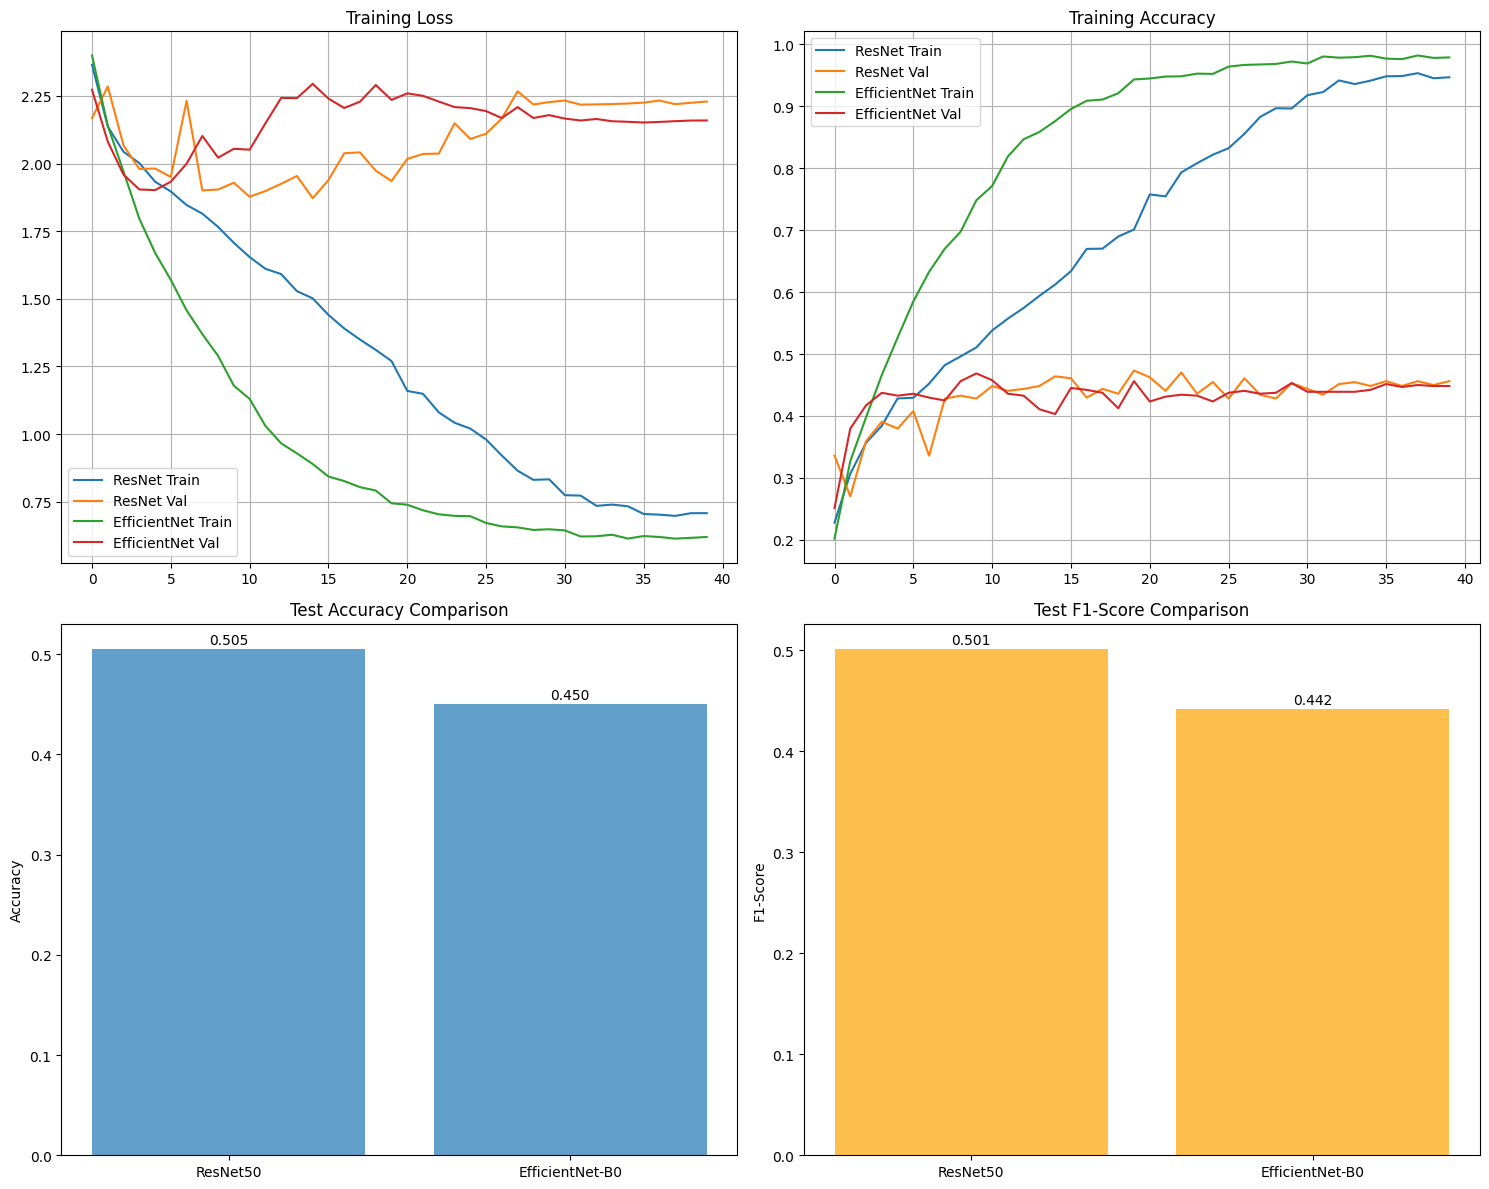

In [13]:
# Cell 13: Results Comparison and Visualization (unchanged aside from variable names)
print("\n=== RESULTS COMPARISON ===")
print("\nResNet50 Results:")
print(f"Expression - Accuracy: {resnet_results['expression']['accuracy']:.4f}, "
      f"F1: {resnet_results['expression']['f1']:.4f}, "
      f"Kappa: {resnet_results['expression']['kappa']:.4f}")
print(f"Valence - RMSE: {resnet_results['valence']['rmse']:.4f}, "
      f"CORR: {resnet_results['valence']['corr']:.4f}, "
      f"CCC: {resnet_results['valence']['ccc']:.4f}, "
      f"SAGR: {resnet_results['valence']['sagr']:.4f}")
print(f"Arousal - RMSE: {resnet_results['arousal']['rmse']:.4f}, "
      f"CORR: {resnet_results['arousal']['corr']:.4f}, "
      f"CCC: {resnet_results['arousal']['ccc']:.4f}, "
      f"SAGR: {resnet_results['arousal']['sagr']:.4f}")

print("\nEfficientNet-B0 Results:")
print(f"Expression - Accuracy: {effnet_results['expression']['accuracy']:.4f}, "
      f"F1: {effnet_results['expression']['f1']:.4f}, "
      f"Kappa: {effnet_results['expression']['kappa']:.4f}")
print(f"Valence - RMSE: {effnet_results['valence']['rmse']:.4f}, "
      f"CORR: {effnet_results['valence']['corr']:.4f}, "
      f"CCC: {effnet_results['valence']['ccc']:.4f}, "
      f"SAGR: {effnet_results['valence']['sagr']:.4f}")
print(f"Arousal - RMSE: {effnet_results['arousal']['rmse']:.4f}, "
      f"CORR: {effnet_results['arousal']['corr']:.4f}, "
      f"CCC: {effnet_results['arousal']['ccc']:.4f}, "
      f"SAGR: {effnet_results['arousal']['sagr']:.4f}")

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss curves
axes[0, 0].plot(resnet_train_losses, label='ResNet Train')
axes[0, 0].plot(resnet_val_losses, label='ResNet Val')
axes[0, 0].plot(effnet_train_losses, label='EfficientNet Train')
axes[0, 0].plot(effnet_val_losses, label='EfficientNet Val')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy curves
axes[0, 1].plot(resnet_train_accs, label='ResNet Train')
axes[0, 1].plot(resnet_val_accs, label='ResNet Val')
axes[0, 1].plot(effnet_train_accs, label='EfficientNet Train')
axes[0, 1].plot(effnet_val_accs, label='EfficientNet Val')
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Performance comparison
models_list = ['ResNet50', 'EfficientNet-B0']
accuracies = [resnet_results['expression']['accuracy'], effnet_results['expression']['accuracy']]
f1_scores = [resnet_results['expression']['f1'], effnet_results['expression']['f1']]

axes[1, 0].bar(models_list, accuracies, alpha=0.7)
axes[1, 0].set_title('Test Accuracy Comparison')
axes[1, 0].set_ylabel('Accuracy')
for i, v in enumerate(accuracies):
    axes[1, 0].text(i, v + 0.005, f'{v:.3f}', ha='center')

axes[1, 1].bar(models_list, f1_scores, alpha=0.7, color='orange')
axes[1, 1].set_title('Test F1-Score Comparison')
axes[1, 1].set_ylabel('F1-Score')
for i, v in enumerate(f1_scores):
    axes[1, 1].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()


Sample predictions - ResNet50:


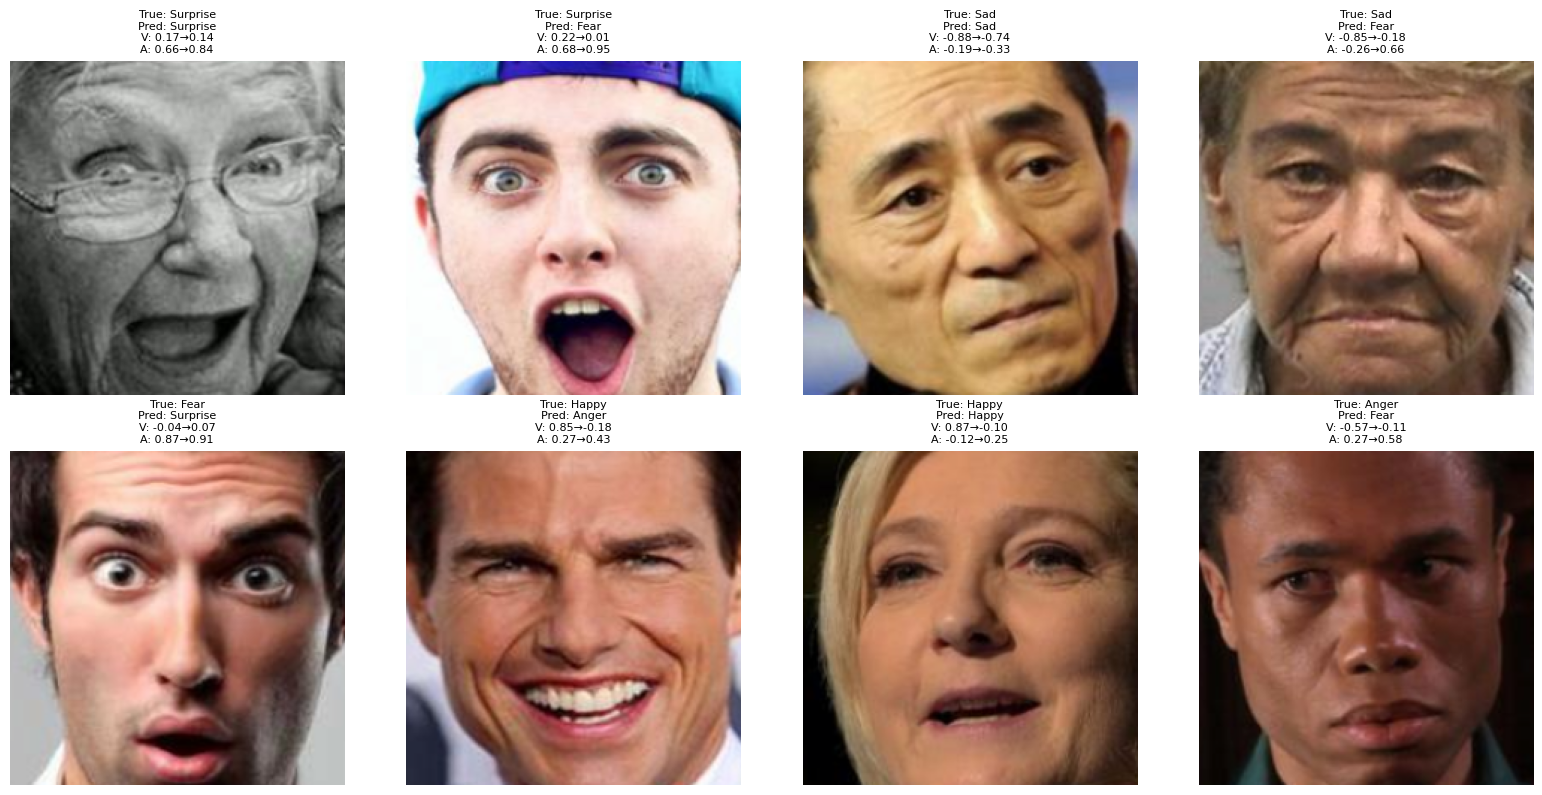

Sample predictions - EfficientNet-B0:


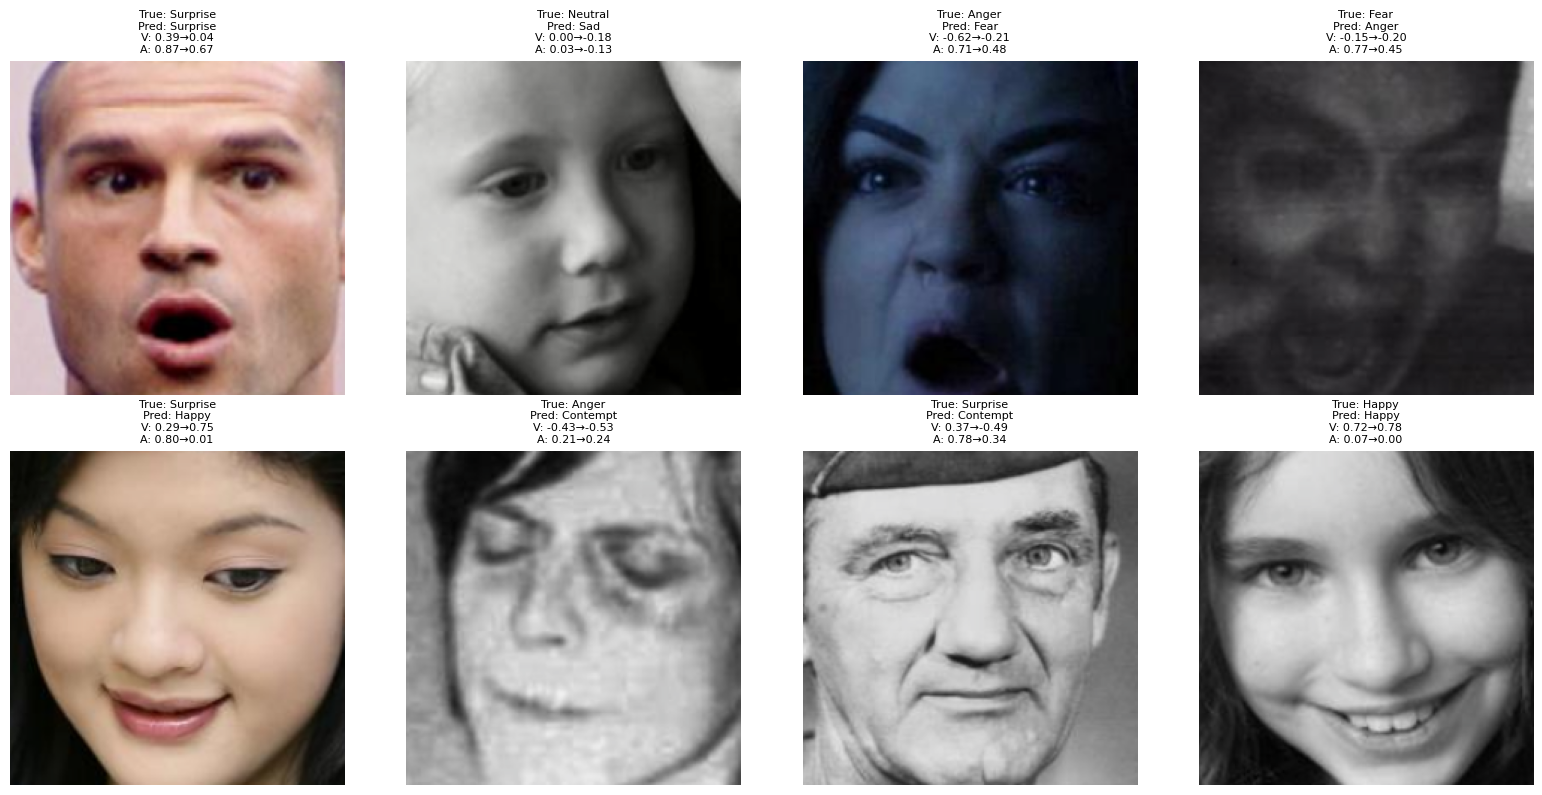


Training completed! Check the generated plots and saved model files.


In [14]:
# Cell 14: Sample Predictions Visualization (unchanged)
def visualize_predictions(model, dataset, device, num_samples=8):
    model.eval()
    emotion_labels = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(device)
            true_exp = sample['expression'].item()
            true_val = sample['valence'].item()
            true_aro = sample['arousal'].item()

            exp_out, val_out, aro_out = model(image)
            pred_exp = torch.argmax(exp_out, dim=1).item()
            pred_val = val_out.item()
            pred_aro = aro_out.item()

            # Denormalize image for display
            img_display = sample['image'].permute(1, 2, 0).cpu().numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            axes[i].imshow(img_display)
            axes[i].set_title(f'True: {emotion_labels[true_exp]}\nPred: {emotion_labels[pred_exp]}\n'
                            f'V: {true_val:.2f}→{pred_val:.2f}\nA: {true_aro:.2f}→{pred_aro:.2f}',
                            fontsize=8)
            axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize predictions for both models
print("Sample predictions - ResNet50:")
visualize_predictions(resnet_model, test_dataset, device)

print("Sample predictions - EfficientNet-B0:")
visualize_predictions(effnet_model, test_dataset, device)

print("\nTraining completed! Check the generated plots and saved model files.")


In [15]:
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
    precision_recall_curve, auc, mean_squared_error
)
from scipy.stats import pearsonr

def evaluate_model(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # --- CATEGORICAL METRICS ---
    metrics = {}
    metrics["Accuracy"] = accuracy_score(y_true, y_pred)
    metrics["F1-Score"] = f1_score(y_true, y_pred, average='weighted')
    metrics["Cohen’s Kappa"] = cohen_kappa_score(y_true, y_pred)

    try:
        metrics["AUC-ROC"] = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except:
        metrics["AUC-ROC"] = "N/A"

    try:
        precision, recall, _ = precision_recall_curve(y_true, y_prob.argmax(axis=1))
        metrics["AUC-PR"] = auc(recall, precision)
    except:
        metrics["AUC-PR"] = "N/A"

    # --- CONTINUOUS METRICS ---
    y_true_cont = y_true.astype(float)
    y_pred_cont = y_pred.astype(float)

    metrics["RMSE"] = np.sqrt(mean_squared_error(y_true_cont, y_pred_cont))
    metrics["Correlation"], _ = pearsonr(y_true_cont, y_pred_cont)
    metrics["SAGR"] = np.mean(np.sign(y_true_cont) == np.sign(y_pred_cont))

    mean_true = np.mean(y_true_cont)
    mean_pred = np.mean(y_pred_cont)
    var_true = np.var(y_true_cont)
    var_pred = np.var(y_pred_cont)
    cov = np.cov(y_true_cont, y_pred_cont)[0, 1]
    metrics["CCC"] = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

    return metrics

# ⚡ Evaluate both models
print("🔎 Evaluating ResNet...")
resnet_metrics = evaluate_model(resnet_model, test_loader, device)

print("\n🔎 Evaluating EfficientNet...")
efficientnet_metrics = evaluate_model(efficientnet_model, test_loader, device)

# 📊 Display side-by-side comparison
print("\n📈 MODEL PERFORMANCE COMPARISON")
header = f"{'Metric':<20} {'ResNet':<20} {'EfficientNet':<20}"
print(header)
print("-" * len(header))
for key in resnet_metrics.keys():
    res_val = resnet_metrics[key]
    eff_val = efficientnet_metrics[key]

    if isinstance(res_val, float):
        res_val = f"{res_val:.4f}"
    if isinstance(eff_val, float):
        eff_val = f"{eff_val:.4f}"

    print(f"{key:<20} {res_val:<20} {eff_val:<20}")


🔎 Evaluating ResNet...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


ValueError: too many values to unpack (expected 2)